# Day 3: Logistic Regression — 泰坦尼克幸存者预测

用逻辑回归做二分类：预测泰坦尼克号乘客是否幸存。

- **模型**: Sigmoid + 二元交叉熵损失
- **数据**: Titanic 数据集（pandas 版，891 条）
- **评估**: 准确率 + 混淆矩阵

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from models.logistic_regression import LogisticRegression

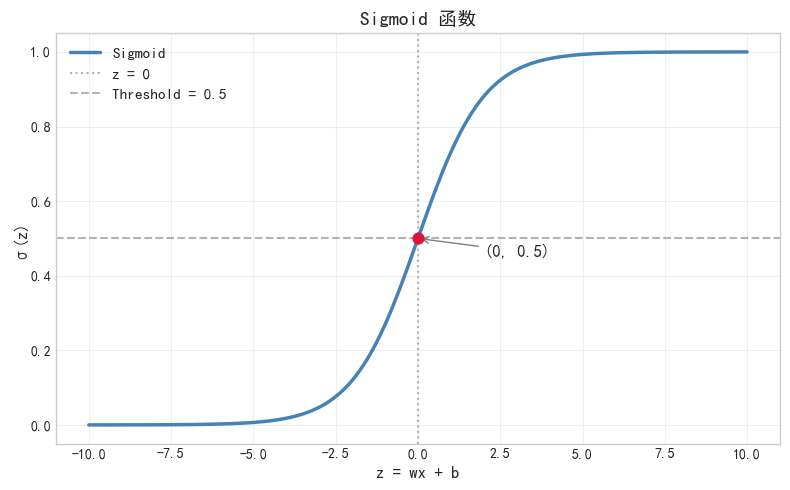

In [2]:
# Sigmoid 函数可视化
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, sigmoid, linewidth=2.5, color='steelblue', label='Sigmoid')
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.6, label='z = 0')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.6, label='Threshold = 0.5')
ax.scatter([0], [0.5], color='crimson', s=60, zorder=5)
ax.annotate('(0, 0.5)', xy=(0, 0.5), xytext=(2, 0.45),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12)
ax.set_xlabel('z = wx + b', fontsize=12)
ax.set_ylabel('σ(z)', fontsize=12)
ax.set_title('Sigmoid 函数', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
df = pd.read_csv("../data/titanic_train.csv")
print(f"Shape: {df.shape}")
print(f"Survived distribution:\n{df['Survived'].value_counts()}")
df.head()

Shape: (891, 12)
Survived distribution:
Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. 特征工程

选取跟生存概率相关的特征：
- **Pclass**: 船舱等级（1/2/3），序数特征
- **Sex**: 性别，二值编码（male=1）
- **Age**: 年龄，数值型，用中位数填充缺失
- **SibSp**: 同行的兄弟姐妹/配偶数
- **Parch**: 同行的父母/子女数
- **Fare**: 票价，数值型
- **Embarked**: 登船港口（C/Q/S），独热编码

In [4]:
# 选特征，删掉无关列
y = df["Survived"].values.astype(np.float64)

# --- Pclass: 直接取 ---
Pclass = df["Pclass"].values.astype(np.float64)

# --- Sex: male=1, female=0 ---
Sex = (df["Sex"].values == "male").astype(np.float64)

# --- Age: 中位数填充 ---
Age = df["Age"].fillna(df["Age"].median()).values.astype(np.float64)

# --- SibSp, Parch, Fare ---
SibSp = df["SibSp"].values.astype(np.float64)
Parch = df["Parch"].values.astype(np.float64)
Fare = df["Fare"].fillna(df["Fare"].median()).values.astype(np.float64)

# --- Embarked: 独热编码 ---
Embarked = df["Embarked"].fillna("S").values
Emb_C = (Embarked == "C").astype(np.float64)
Emb_Q = (Embarked == "Q").astype(np.float64)
# Emb_S 作为基准，省略避免多重共线性

# 合并所有特征
X = np.column_stack([Pclass, Sex, Age, SibSp, Parch, Fare, Emb_C, Emb_Q])
feature_names = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Emb_C", "Emb_Q"]
print(f"Feature matrix: {X.shape}")

Feature matrix: (891, 8)


## 2. 拆分 + 标准化

In [5]:
def standardize(train, test):
    mean, std = train.mean(0), train.std(0)
    std[std == 0] = 1
    return (train - mean) / std, (test - mean) / std

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test = standardize(X_train, X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive ratio: {y_train.mean():.3f}")
print(f"Test positive ratio: {y_test.mean():.3f}")

Train: (712, 8), Test: (179, 8)
Train positive ratio: 0.376
Test positive ratio: 0.413


## 3. 定义评估函数

In [6]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def evaluate(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    acc = accuracy(y, y_pred)
    # 二元交叉熵损失
    eps = 1e-8
    loss = -np.mean(y * np.log(y_prob + eps) + (1 - y) * np.log(1 - y_prob + eps))
    return acc, loss

def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

## 4. 训练逻辑回归模型

In [7]:
model = LogisticRegression(lr=0.1, epochs=5000)
model.fit(X_train, y_train)

train_acc, train_loss = evaluate(model, X_train, y_train)
test_acc, test_loss = evaluate(model, X_test, y_test)
print(f"Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"Test  — Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

Train — Loss: 0.4482, Acc: 0.8006
Test  — Loss: 0.4156, Acc: 0.8101


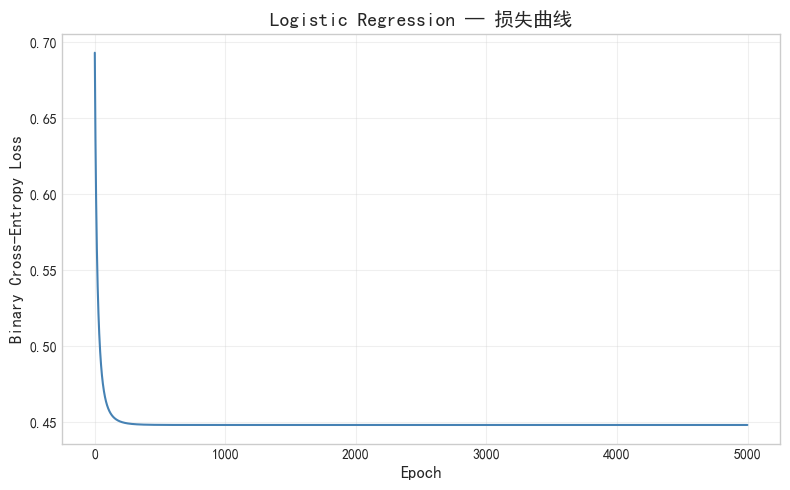

In [8]:
# 损失曲线
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(model.losses, linewidth=1.5, color='steelblue')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax.set_title('Logistic Regression — 损失曲线', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 权重分析

逻辑回归的权重代表每个特征对 log-odds（对数几率）的影响方向和大小。
正权重意味着该特征值越大，幸存概率越高；负权重则相反。

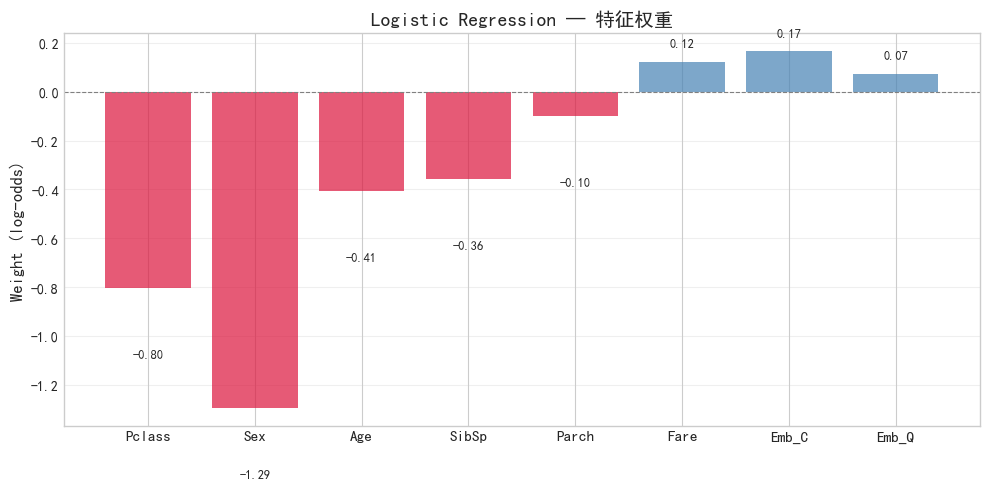

In [9]:
# 权重条形图
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['crimson' if w < 0 else 'steelblue' for w in model.w]
bars = ax.bar(range(len(model.w)), model.w, color=colors, alpha=0.7)
ax.set_xticks(range(len(model.w)))
ax.set_xticklabels(feature_names, fontsize=11)
ax.set_ylabel('Weight (log-odds)', fontsize=12)
ax.set_title('Logistic Regression — 特征权重', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', ls='--', lw=0.8)
ax.grid(True, alpha=0.3, axis='y')

# 在柱子上方标注数值
for i, w in enumerate(model.w):
    ax.text(i, w + (0.05 if w >= 0 else -0.25), f'{w:.2f}',
            ha='center', va='bottom' if w >= 0 else 'top', fontsize=9)
plt.tight_layout()
plt.show()

## 6. 混淆矩阵

Confusion Matrix:
[[90 15]
 [19 55]]
TN=90, FP=15, FN=19, TP=55


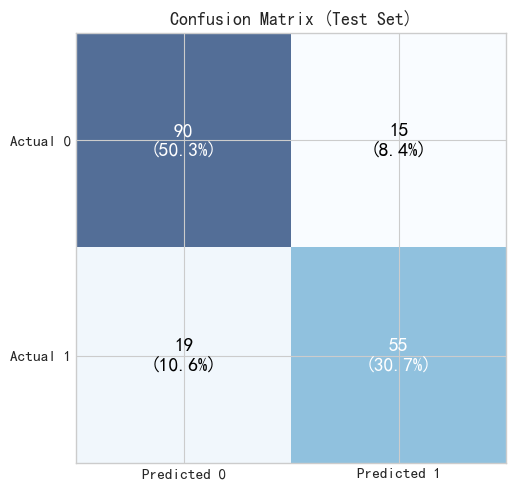

Accuracy:  0.8101
Precision: 0.7857
Recall:    0.7432
F1-score:  0.7639


In [53]:
y_pred_test = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix:")
print(cm)
print(f"TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', alpha=0.7)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted 0', 'Predicted 1'], fontsize=11)
ax.set_yticklabels(['Actual 0', 'Actual 1'], fontsize=11)
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]}\n({cm[i, j]/cm.sum():.1%})',
                ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

## 7. 与 sklearn 对比验证

用 sklearn 的 LogisticRegression 在同样的数据上跑一遍，验证我们的实现是否正确。

In [11]:
from sklearn.linear_model import LogisticRegression as SKLogistic

sk_model = SKLogistic(C=1e10, solver='liblinear', random_state=42)  # C 很大 ≈ 无正则化
sk_model.fit(X_train, y_train)

sk_train_acc = sk_model.score(X_train, y_train)
sk_test_acc = sk_model.score(X_test, y_test)
print(f"{'Model':<20} {'Train Acc':<12} {'Test Acc':<12}")
print('-'*44)
print(f"{'Ours':<20} {train_acc:<12.4f} {test_acc:<12.4f}")
print(f"{'sklearn':<20} {sk_train_acc:<12.4f} {sk_test_acc:<12.4f}")

# 对比权重
print(f"\n权重对比:")
for i, name in enumerate(feature_names):
    print(f"  {name:<8}  ours={model.w[i]:+.4f}  sklearn={sk_model.coef_[0][i]:+.4f}")

Model                Train Acc    Test Acc    
--------------------------------------------
Ours                 0.8006       0.8101      
sklearn              0.8006       0.8101      

权重对比:
  Pclass    ours=-0.8017  sklearn=-0.8017
  Sex       ours=-1.2944  sklearn=-1.2944
  Age       ours=-0.4067  sklearn=-0.4067
  SibSp     ours=-0.3580  sklearn=-0.3580
  Parch     ours=-0.0997  sklearn=-0.0997
  Fare      ours=+0.1228  sklearn=+0.1228
  Emb_C     ours=+0.1662  sklearn=+0.1662
  Emb_Q     ours=+0.0741  sklearn=+0.0741


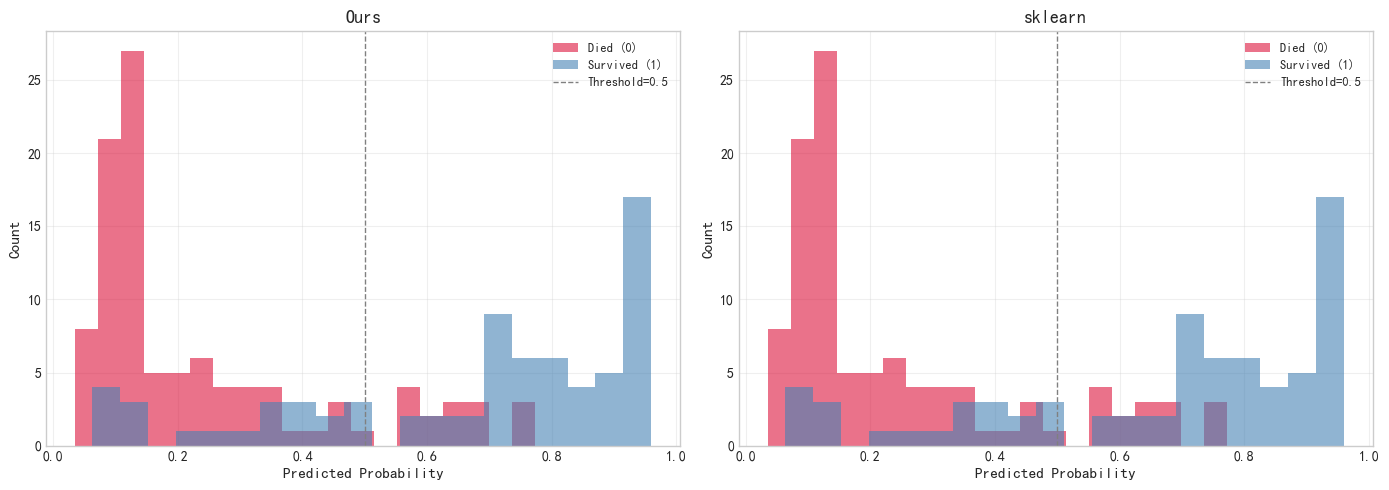

In [12]:
# 概率分布对比：我们的模型 vs sklearn
y_prob_ours = model.predict_proba(X_test)
y_prob_sk = sk_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title in [
    (axes[0], y_prob_ours, 'Ours'),
    (axes[1], y_prob_sk, 'sklearn')
]:
    ax.hist(probs[y_test == 0], bins=20, alpha=0.6, label='Died (0)', color='crimson')
    ax.hist(probs[y_test == 1], bins=20, alpha=0.6, label='Survived (1)', color='steelblue')
    ax.axvline(x=0.5, color='gray', ls='--', lw=1, label='Threshold=0.5')
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 结果汇总

In [13]:
print('='*50)
print('Titanic — Logistic Regression 结果')
print('='*50)
print(f"{'Metric':<15} {'Value':<10}")
print('-'*25)
print(f"{'Train Acc':<15} {train_acc:<10.4f}")
print(f"{'Test Acc':<15} {test_acc:<10.4f}")
print(f"{'Precision':<15} {precision:<10.4f}")
print(f"{'Recall':<15} {recall:<10.4f}")
print(f"{'F1-score':<15} {f1:<10.4f}")
print('='*50)
print(f"Top positive feature: Sex (women more likely to survive)")
print(f"Top negative feature: Pclass (lower class = higher risk)")

Titanic — Logistic Regression 结果
Metric          Value     
-------------------------
Train Acc       0.8006    
Test Acc        0.8101    
Precision       0.7857    
Recall          0.7432    
F1-score        0.7639    
Top positive feature: Sex (women more likely to survive)
Top negative feature: Pclass (lower class = higher risk)
